# Set up

In [24]:
!pip install xgboost

In [14]:
import pandas as pd
from scipy.spatial.distance import cosine
from collections import defaultdict
import numpy as np
import networkx as nx
import random
import torch
from tqdm import tqdm
from torch_geometric.utils import from_networkx
from torch_geometric.nn import Node2Vec

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from pathlib import Path

In [2]:
import os
def set_seed(seed):
    """
    Sets the random seed for reproducibility across Python, NumPy, and PyTorch.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # For hash-based operations
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Example usage:
seed_value = 42
set_seed(seed_value)

# Load Hetionet

In [3]:
# Load nodes
nodes_df = pd.read_csv("hetionet-v1.0-nodes.tsv", sep="\t")
# Load edges
edges_df = pd.read_csv("hetionet-v1.0-edges.sif.gz", sep="\t", compression='gzip')

# combine all unique nodes from the edges_df
unique_nodes = list(edges_df.source.unique()) + list(edges_df.target.unique())
unique_nodes = list(set(unique_nodes))
unique_nodes.sort()

# get the list of unique edge types
unique_edge_types = list(edges_df.metaedge.unique())
edge_type_size = len(unique_edge_types)

# assign unique node ids
node_id_map = {node: idx+1 for idx, node in enumerate(unique_nodes)}
# assign unique edge type ids
edge_type_id_map = {edge: idx+1 for idx, edge in enumerate(unique_edge_types)}

# add unique node ids to the nodes_df for ease of queries
nodes_df['unique_node_id'] = [node_id_map[x]  if x in node_id_map else None for x in nodes_df['id']]
nodes_df

,id,name,kind,unique_node_id
0,Anatomy::UBERON:0000002,uterine cervix,Anatomy,1.0
1,Anatomy::UBERON:0000004,nose,Anatomy,2.0
2,Anatomy::UBERON:0000006,islet of Langerhans,Anatomy,3.0
3,Anatomy::UBERON:0000007,pituitary gland,Anatomy,4.0
4,Anatomy::UBERON:0000010,peripheral nervous system,Anatomy,5.0
...,...,...,...,...
47026,Symptom::D064250,Hypertriglyceridemic Waist,Symptom,45156.0
47027,Symptom::D065634,Cerebrospinal Fluid Leak,Symptom,45157.0
47028,Symptom::D065635,Benign Paroxysmal Positional Vertigo,Symptom,45158.0
47029,Symptom::D065906,Hyperlactatemia,Symptom,NaN


In [4]:
mapped_edges_df = pd.DataFrame({
	"src_id": edges_df['source'].map(node_id_map),
	"dst_id": edges_df['target'].map(node_id_map),
	"type": edges_df['metaedge'].map(edge_type_id_map),
	"edge_id": range(1, len(edges_df)+1)
})
mapped_edges_df[:3]

,src_id,dst_id,type,edge_id
0,32772,9085,1,1
1,25550,10083,1,2
2,18773,7988,1,3


# Create NetworkX

In [5]:
# create an edge list
edge_list = [
    (row.src_id, row.dst_id, {"type": row.type, "edge_id": row.edge_id, "weight": 1.0})
    for row in mapped_edges_df.itertuples()
]
G = nx.Graph(edge_list)

In [6]:
# find alzheimer's disease node name
ad = nodes_df[(nodes_df['kind'] == 'Disease') & (nodes_df['name'] == 'Alzheimer\'s disease')]
# get AD's unique node ID
ad_id = node_id_map[ad.iloc[0, 0]]
print(f'AD unique node id: {ad_id}\n')

AD unique node id: 14723



# Positive and negative edge sampling

In [7]:
all_genes = list(nodes_df['unique_node_id'][nodes_df['kind'] == 'Gene'])
all_genes = [x for x in all_genes if str(x) != 'nan'] # clean out nan
positive_genes = [ n for n in G.neighbors(ad_id) if n in all_genes]
positive_pairs = [(g, ad_id) for g in positive_genes]

positive_set = set(positive_genes)
negative_genes = [
    g for g in all_genes
    if not G.has_edge(g, ad_id)
]

# Sample to balance positives and negatives
negative_genes_sampled = random.sample(negative_genes, len(positive_genes))
negative_pairs = [(g, ad_id) for g in negative_genes_sampled]

all_pairs = positive_pairs + negative_pairs
labels = [1] * len(positive_pairs) + [0] * len(negative_pairs)

# PyG Node2Vec

In [8]:
def pair_features(gene_id, disease_id, emb_df, method="concat"):
    if gene_id in emb_df.index and disease_id in emb_df.index:
        a = emb_df.loc[gene_id].values
        b = emb_df.loc[disease_id].values
        if method == "concat":
            return np.concatenate([a, b])
        elif method == "diff":
            return a - b
        elif method == "hadamard":
            return a * b
    return None

In [9]:
def train(model, loader, optimizer, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for pos_rw, neg_rw in tqdm(loader, desc=f"Epoch {epoch+1}"):
            pos_rw = pos_rw.to(device)
            neg_rw = neg_rw.to(device)
            optimizer.zero_grad()
            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        #print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

In [10]:
from sklearn.model_selection import ParameterGrid

grid = ParameterGrid({
	'dimensions': [128],
    'walk_length': [5, 10, 20, 50], # 5, 10, 20
    'num_walks': [5, 10, 25],
	'p': [2, 1, 0.5], #2, 1, 0.5
	'q': [2, 1, 0.5], #2, 1, 0.5
    'epoch': [5]
})

In [11]:
G_data = from_networkx(G)
edge_index = G_data.edge_index

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [17]:
rez = pd.DataFrame.from_dict(grid)
rez['accuracy'] = float()

for idx, params in enumerate(grid):
    params_string = '_'.join(str(key) + str(value) for key, value in params.items())
    output_file_name = 'hetio_node2vec_' + params_string + '.txt'

    if Path(output_file_name).is_file():
        df = pd.read_csv(output_file_name, skiprows=1, header=None, index_col=[0])
        df.index.name = "node_id"       
    else:
        n2v_model = Node2Vec(
            edge_index=edge_index,
            embedding_dim=params['dimensions'],
            walk_length=params['walk_length'],
            context_size=2,
            walks_per_node=params['num_walks'],
            num_negative_samples=5,
            p=params['p'],
            q=params['q'],
            sparse=True
        ).to(device)
    
        loader = n2v_model.loader(batch_size=256, shuffle=True)
        optimizer = torch.optim.SparseAdam(n2v_model.parameters(), lr=0.01)
    
        train(n2v_model, loader, optimizer, device, epochs=params['epoch'])
        
        # convert the embedding to pandas data frame
        embeddings = n2v_model.embedding.weight.detach().cpu().numpy()
        
        node_ids = list(G.nodes())
        df = pd.DataFrame(embeddings, index=node_ids)
        df.index.name = 'node_id'
        df.to_csv(output_file_name, index=True)
    
    X = np.array([
            pair_features(g, d, df)
            for g, d in all_pairs
            if pair_features(g, d, df) is not None
        ])
    y = np.array(labels[:len(X)])
    # split for training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)
    # run XGBoost classifier
    xgboost_model = xgb.XGBClassifier(eval_metric="logloss")
    xgboost_model.fit(X_train, y_train)
    
    y_pred = xgboost_model.predict_proba(X_test)[:, 1]
    print(f'Test parameters: {params}')
    print("Test AUC:", roc_auc_score(y_test, y_pred))
    rez.loc[idx, 'accuracy'] = roc_auc_score(y_test, y_pred)

Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 2, 'walk_length': 5}
Test AUC: 0.5625233097128243
Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 2, 'walk_length': 10}
Test AUC: 0.5976343971442273
Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 2, 'walk_length': 20}
Test AUC: 0.6070115616175609
Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 2, 'walk_length': 50}
Test AUC: 0.6947626405242687
Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 1, 'walk_length': 5}
Test AUC: 0.6401513133358196
Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 1, 'walk_length': 10}
Test AUC: 0.6554424849485855
Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 1, 'walk_length': 20}
Test AUC: 0.6667909851350632
Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 5, 'p': 2, 'q': 1, 'walk_length': 50}

Epoch 5: 100%|██████████████████████████████████████████████████████████████████████████████| 177/177 [00:04<00:00, 41.39it/s]


Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 25, 'p': 2, 'q': 0.5, 'walk_length': 5}
Test AUC: 0.6557621610101764


Epoch 5: 100%|██████████████████████████████████████████████████████████████████████████████| 177/177 [00:08<00:00, 21.18it/s]


Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 25, 'p': 2, 'q': 0.5, 'walk_length': 10}
Test AUC: 0.6801108210346849


...

Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 25, 'p': 0.5, 'q': 0.5, 'walk_length': 10}
Test AUC: 0.6839469337737759


Epoch 5: 100%|██████████████████████████████████████████████████████████████████████████████| 177/177 [00:17<00:00, 10.13it/s]


Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 25, 'p': 0.5, 'q': 0.5, 'walk_length': 20}
Test AUC: 0.7069636102083223


Epoch 5: 100%|██████████████████████████████████████████████████████████████████████████████| 177/177 [00:44<00:00,  3.94it/s]


Test parameters: {'dimensions': 128, 'epoch': 5, 'num_walks': 25, 'p': 0.5, 'q': 0.5, 'walk_length': 50}
Test AUC: 0.7779316958815068


In [ ]:
rez.to_csv('hetionet_node2vec_xgboost_accuracy.csv', index=False)

In [ ]:
rez.sort_values(by=['accuracy'])

In [51]:
# Create cosine similarity

In [15]:
node2vec_df = pd.read_csv("hetio_node2vec_dimensions128_epoch5_num_walks5_p2_q2_walk_length10.txt", skiprows=1, header=None, index_col=[0])
node2vec_df.index.name = "node_id"
node2vec_df.head(n=5)

,1,2,3,4,5,6,7,8,9,10,...,119,120,121,122,123,124,125,126,127,128
node_id,,,,,,,,,,,,,,,,,,,,,
32772,-0.467238,-0.659047,-0.307141,0.394972,0.237425,-0.264333,0.146173,0.813331,0.480877,-0.498903,...,0.228665,0.465714,-0.384492,0.192556,1.165222,0.009782,0.345993,-0.680528,-1.235336,-0.393397
9085,-1.019715,-0.562748,-0.796166,0.578901,-0.471329,-0.184083,-0.028339,1.487329,0.849978,0.115655,...,0.750894,0.397262,-0.526681,0.242265,0.260580,-0.233622,0.190040,-0.386438,-0.343991,0.408343
25550,-0.983916,-0.696114,-0.478849,-0.632049,0.585595,-0.371875,-0.060913,1.007156,-0.015051,-1.016115,...,1.786352,-0.548517,0.630995,0.492149,0.904796,0.383731,0.199745,0.173970,0.178140,1.471254
10083,-1.763896,0.941234,0.745682,0.495652,-0.538443,0.618819,-0.345755,0.768559,-0.057221,-0.282916,...,-0.286114,0.097527,1.852645,-0.289188,-0.036619,-1.833955,0.738736,0.454732,-2.042381,-0.369224
18773,-0.588359,0.085759,-0.018587,-0.099428,-0.376022,0.003440,0.147109,-0.922123,-0.849888,-0.131312,...,-0.169612,-0.265253,-0.201260,-0.656197,-0.784865,1.101931,-0.361150,-0.578934,0.135573,0.910662


In [16]:
# find alzheimer's disease node name
ad = nodes_df[(nodes_df['kind'] == 'Disease') & (nodes_df['name'] == 'Alzheimer\'s disease')]
print(f'AD disease node: {ad}\n')
# get AD embedding
ad_id = node_id_map[ad.iloc[0, 0]]
ad_emb = node2vec_df.loc[ad_id]
# calculate the node distances using embeddings
# Note: this returns cosine *distance* = 1 - cosine similarity
gene_ad_cosine_similarity = defaultdict(float)
for row in nodes_df.itertuples():
    if row.kind != 'Gene': # skip non-Gene nodes
        continue
    if row.id not in node_id_map: # skip disjoint gene nodes
        continue
    # calculate cosine similarity
    gene_emb = node2vec_df.loc[row.unique_node_id]
    cos_sim = cosine(gene_emb, ad_emb)
    gene_ad_cosine_similarity[row.name] = cos_sim

    # print(f'node id = {row.unique_node_id}')
    # print(f'gene_emb = {gene_emb}')
    # print(f'cos_sim = {cos_sim}')

AD disease node:                         id                 name     kind  unique_node_id
14738  Disease::DOID:10652  Alzheimer's disease  Disease         14723.0



In [17]:
# read gene alias name
gene_alias = pd.read_csv("dictionary.csv")
gene_alias.head(n=5)
# add cosine similarity for previous symbols
for row in gene_alias.itertuples():
    approved_symbol = row[2]
	# add the cosine similarity for genes known as its previous symbols
    if row[5] is not np.nan:
        previous_symbols = str(row[5]).split(', ')
        for previous_symbol in previous_symbols:
            if previous_symbol in gene_ad_cosine_similarity:
                gene_ad_cosine_similarity[approved_symbol] = gene_ad_cosine_similarity[previous_symbol]
    # add the cosine similarity for genes known as its alias symbols
    if row[6] is not np.nan:
        alias_symbols = str(row[5]).split(', ')
        for alias_symbol in alias_symbols:
            if alias_symbol in gene_ad_cosine_similarity:
                gene_ad_cosine_similarity[approved_symbol] = gene_ad_cosine_similarity[alias_symbol]

In [18]:
print(f'APOE cosine similarity = {gene_ad_cosine_similarity['APOE']}')
print(f'PTEN cosine similarity = {gene_ad_cosine_similarity['PTEN']}')
print(f'APP cosine similarity = {gene_ad_cosine_similarity['APP']}')
print(f'ACP3 cosine similarity = {gene_ad_cosine_similarity['ACP3']}')

APOE cosine similarity = 0.8467831088203994
PTEN cosine similarity = 0.7581400826187051
APP cosine similarity = 0.7186772753206556
ACP3 cosine similarity = 0.9201620436221638


In [19]:
# cross-check against Alena's gene score
gene_score = pd.read_csv('score_upd_alzkb_mem.csv', header=[0])
# add cosine similarity to the gene score table
gene_score['cosine'] = [gene_ad_cosine_similarity[g] if g in gene_ad_cosine_similarity else None for g in gene_score['Gene']]
print(gene_score.head(n=3))

      Gene  Drugability  Drugability_q  AD Gene  AD Drug  AD Pathway  Drug  \
0   RNASE1        118.0              2        1        1           1     2   
1  SLC22A3         44.2              1        1        1           1     2   
2     CMA1         29.5              1        1        1           1     2   

       btw  BT_q  Score    cosine  
0   1578.4    -2      5  0.972187  
1  82002.9    -1      5  0.873731  
2  59529.4    -1      5  0.837742  


In [ ]:
# save to file
gene_score.to_csv('score_upd_alzkb_mem_node2vec.csv', index=False)

      Gene  Drugability  Drugability_q  AD Gene  AD Drug  AD Pathway  Drug  \
0   RNASE1        118.0              2        1        1           1     2   
1  SLC22A3         44.2              1        1        1           1     2   
2     CMA1         29.5              1        1        1           1     2   

       btw  BT_q  Score    cosine  
0   1578.4    -2      5  0.208472  
1  82002.9    -1      5  0.102075  
2  59529.4    -1      5  0.060850  


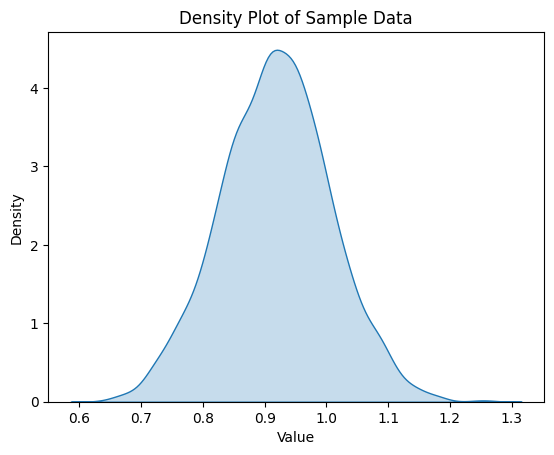

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a density plot
sns.kdeplot(gene_score['cosine'], fill=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Density Plot of Sample Data')
plt.show()